In [12]:
import pymc as pm
import numpy as np
import pandas as pd
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
mean_time_per_sample = pm.Gamma.dist(alpha=14, beta=100)

Text(0.5, 1.0, 'Time per Sample')

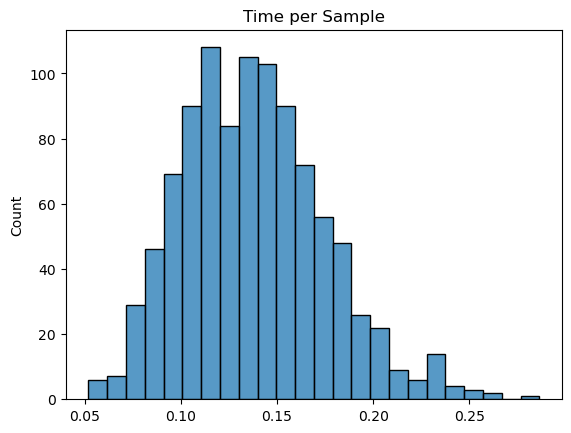

In [14]:
x_draws = pm.draw(mean_time_per_sample, draws=1000, random_seed=1)
ax = sns.histplot(x_draws)
ax.set_title("Time per Sample")

Text(0.5, 1.0, 'year-to-year variation in time-per-sample')

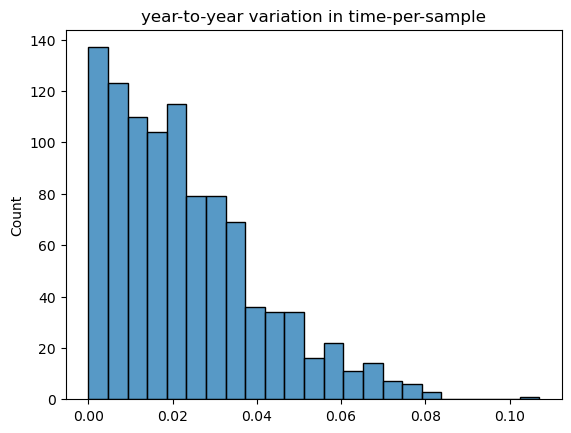

In [15]:
variation = pm.HalfNormal.dist( sigma=0.03)
x_draws = pm.draw(variation, draws=1000, random_seed=1)
ax = sns.histplot(x_draws)
ax.set_title('year-to-year variation in time-per-sample')

Text(0.5, 1.0, 'End Date')

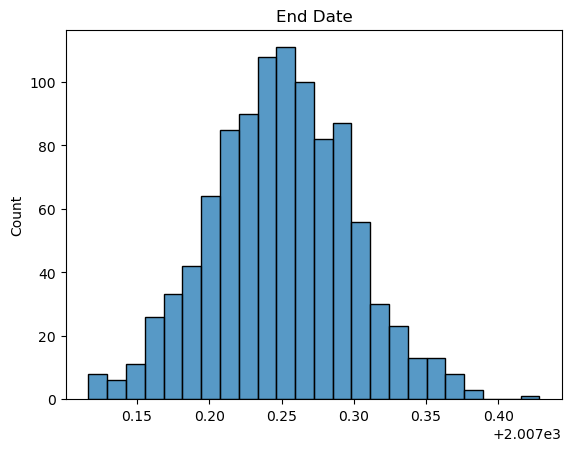

In [16]:
collection_date = 2007.25  # April 2007
last_age_H = pm.Normal.dist( mu=collection_date, sigma=0.05) # Sigma can be =0.01 
x_draws = pm.draw(last_age_H, draws=1000, random_seed=1)
ax = sns.histplot(x_draws)
ax.set_title('End Date')


    TIME INCREMENTS for path H
    - One for each transition between samples (n-1 increments)
    - Lognormal ensures all positive (time can't go backward)
    - mu = log(mean_time_per_sample) centers around our belief
    - Each increment is slightly different (controlled by 'variation')


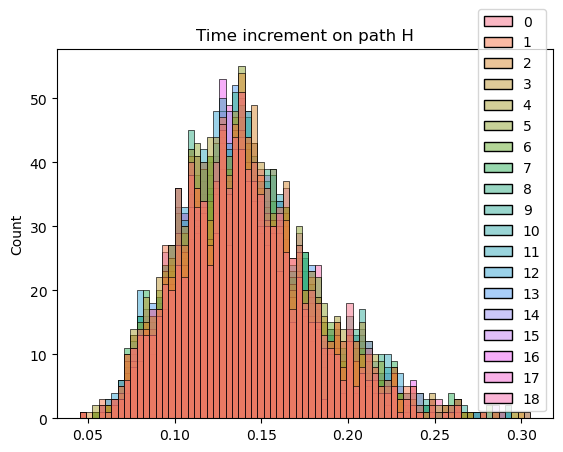

In [17]:
#n_H = 113  # Actual length of path H
n_H = 20
time_inc_H = pm.Lognormal.dist(mu=np.log(mean_time_per_sample),
                          sigma=variation,
                          shape=n_H - 1)

x_draws = pm.draw(time_inc_H, draws=1000, random_seed=1) 
ax = sns.histplot(x_draws)
ax.set_title('Time increment on path H')

print('''
    TIME INCREMENTS for path H
    - One for each transition between samples (n-1 increments)
    - Lognormal ensures all positive (time can't go backward)
    - mu = log(mean_time_per_sample) centers around our belief
    - Each increment is slightly different (controlled by 'variation')''')

In [18]:
cumsum_H = pt.concatenate([[0], pt.cumsum(time_inc_H)])
cumsum_H

Join.0

In [19]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [20]:
# True parameter values
alpha, sigma = 1, 1
beta = [1, 2.5]

# Size of dataset
size = 100

# Predictor variable
X1 = np.random.randn(size)
X2 = np.random.randn(size) * 0.2

# Simulate outcome variable
Y = alpha + beta[0] * X1 + beta[1] * X2 + rng.normal(size=size) * sigma

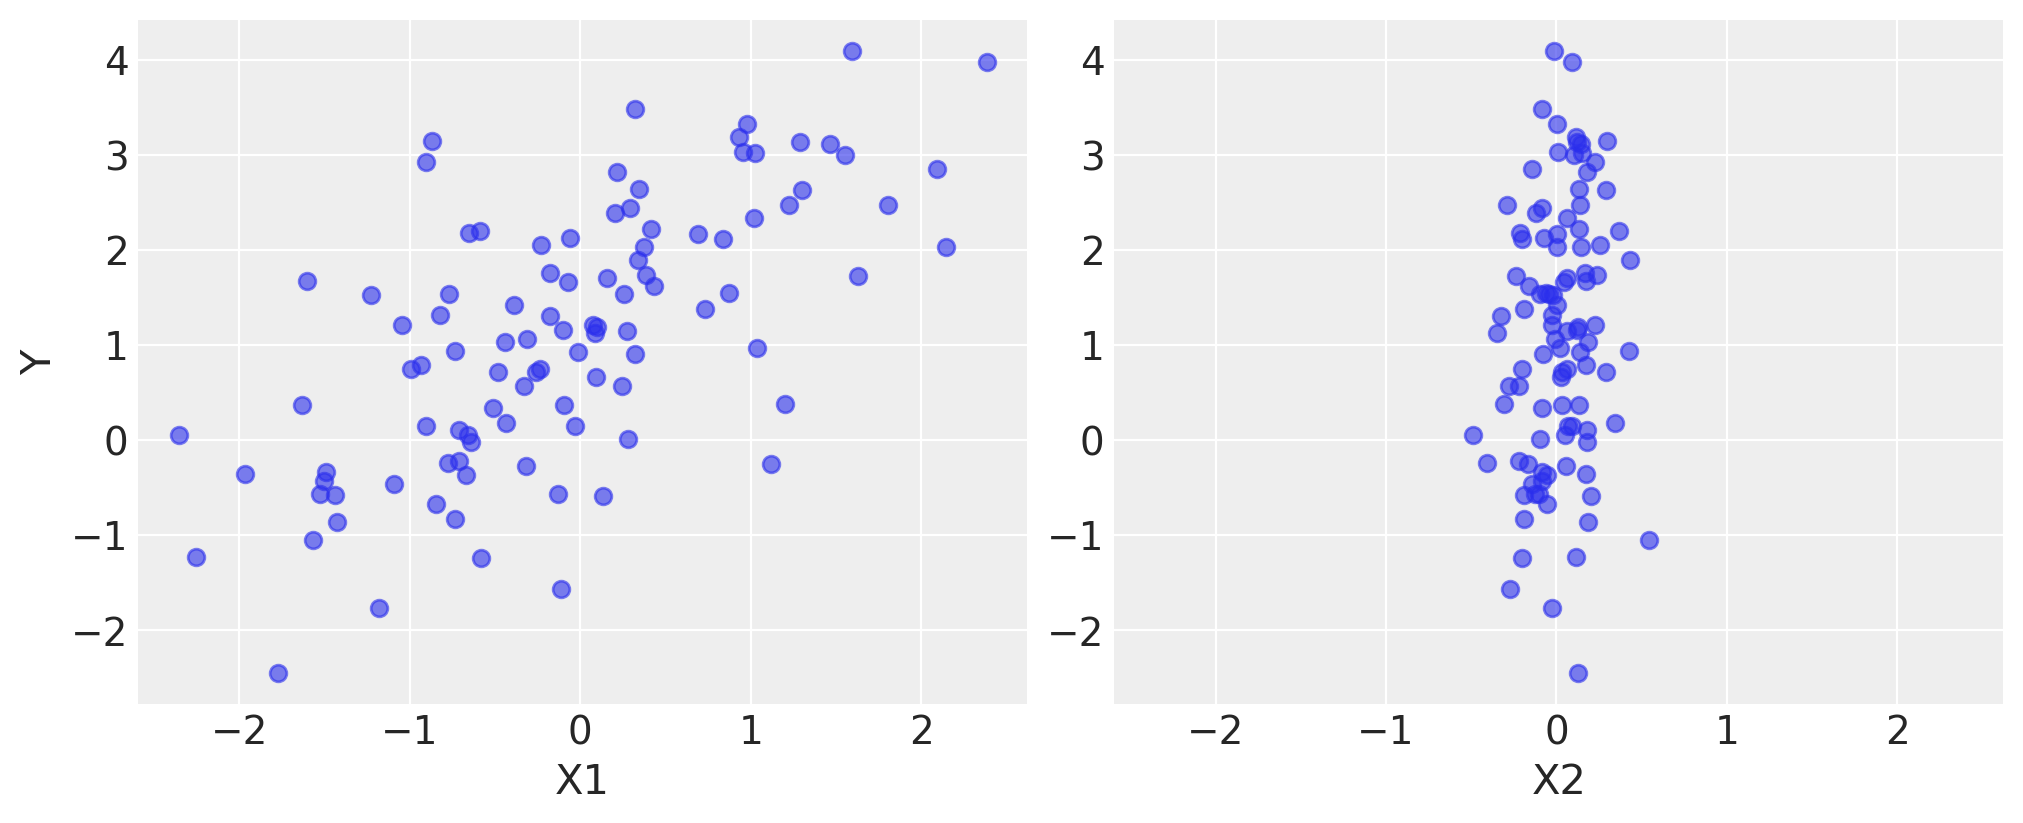

In [21]:
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(10, 4))
axes[0].scatter(X1, Y, alpha=0.6)
axes[1].scatter(X2, Y, alpha=0.6)
axes[0].set_ylabel("Y")
axes[0].set_xlabel("X1")
axes[1].set_xlabel("X2");

In [22]:
print(f"Running on PyMC v{pm.__version__}")


Running on PyMC v5.27.1


In [23]:
basic_model = pm.Model()

with basic_model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    mu = alpha + beta[0] * X1 + beta[1] * X2

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=Y)

    # draw 1000 posterior samples
    idata = pm.sample()



C:\Users\mkara\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 19 seconds.


In [24]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [25]:
idata.posterior["alpha"].sel(draw=slice(0, 4))


<xarray.DataArray 'alpha' (chain: 4, draw: 5)> Size: 160B
array([[1.09896645, 1.34151987, 1.11330196, 1.21729217, 1.15164456],
       [1.19261509, 1.1157009 , 1.2203774 , 1.10444466, 1.15855177],
       [1.3262396 , 1.11302105, 1.23953451, 1.15694536, 1.2413112 ],
       [1.08895736, 1.26189576, 1.09288086, 1.14699963, 1.15808024]])
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 40B 0 1 2 3 4

In [26]:
with basic_model:
    # instantiate sampler
    step = pm.Slice()

    # draw 5000 posterior samples
    slice_idata = pm.sample(5000, step=step)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Slice: [alpha]
>Slice: [beta]
>Slice: [sigma]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 20 seconds.


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

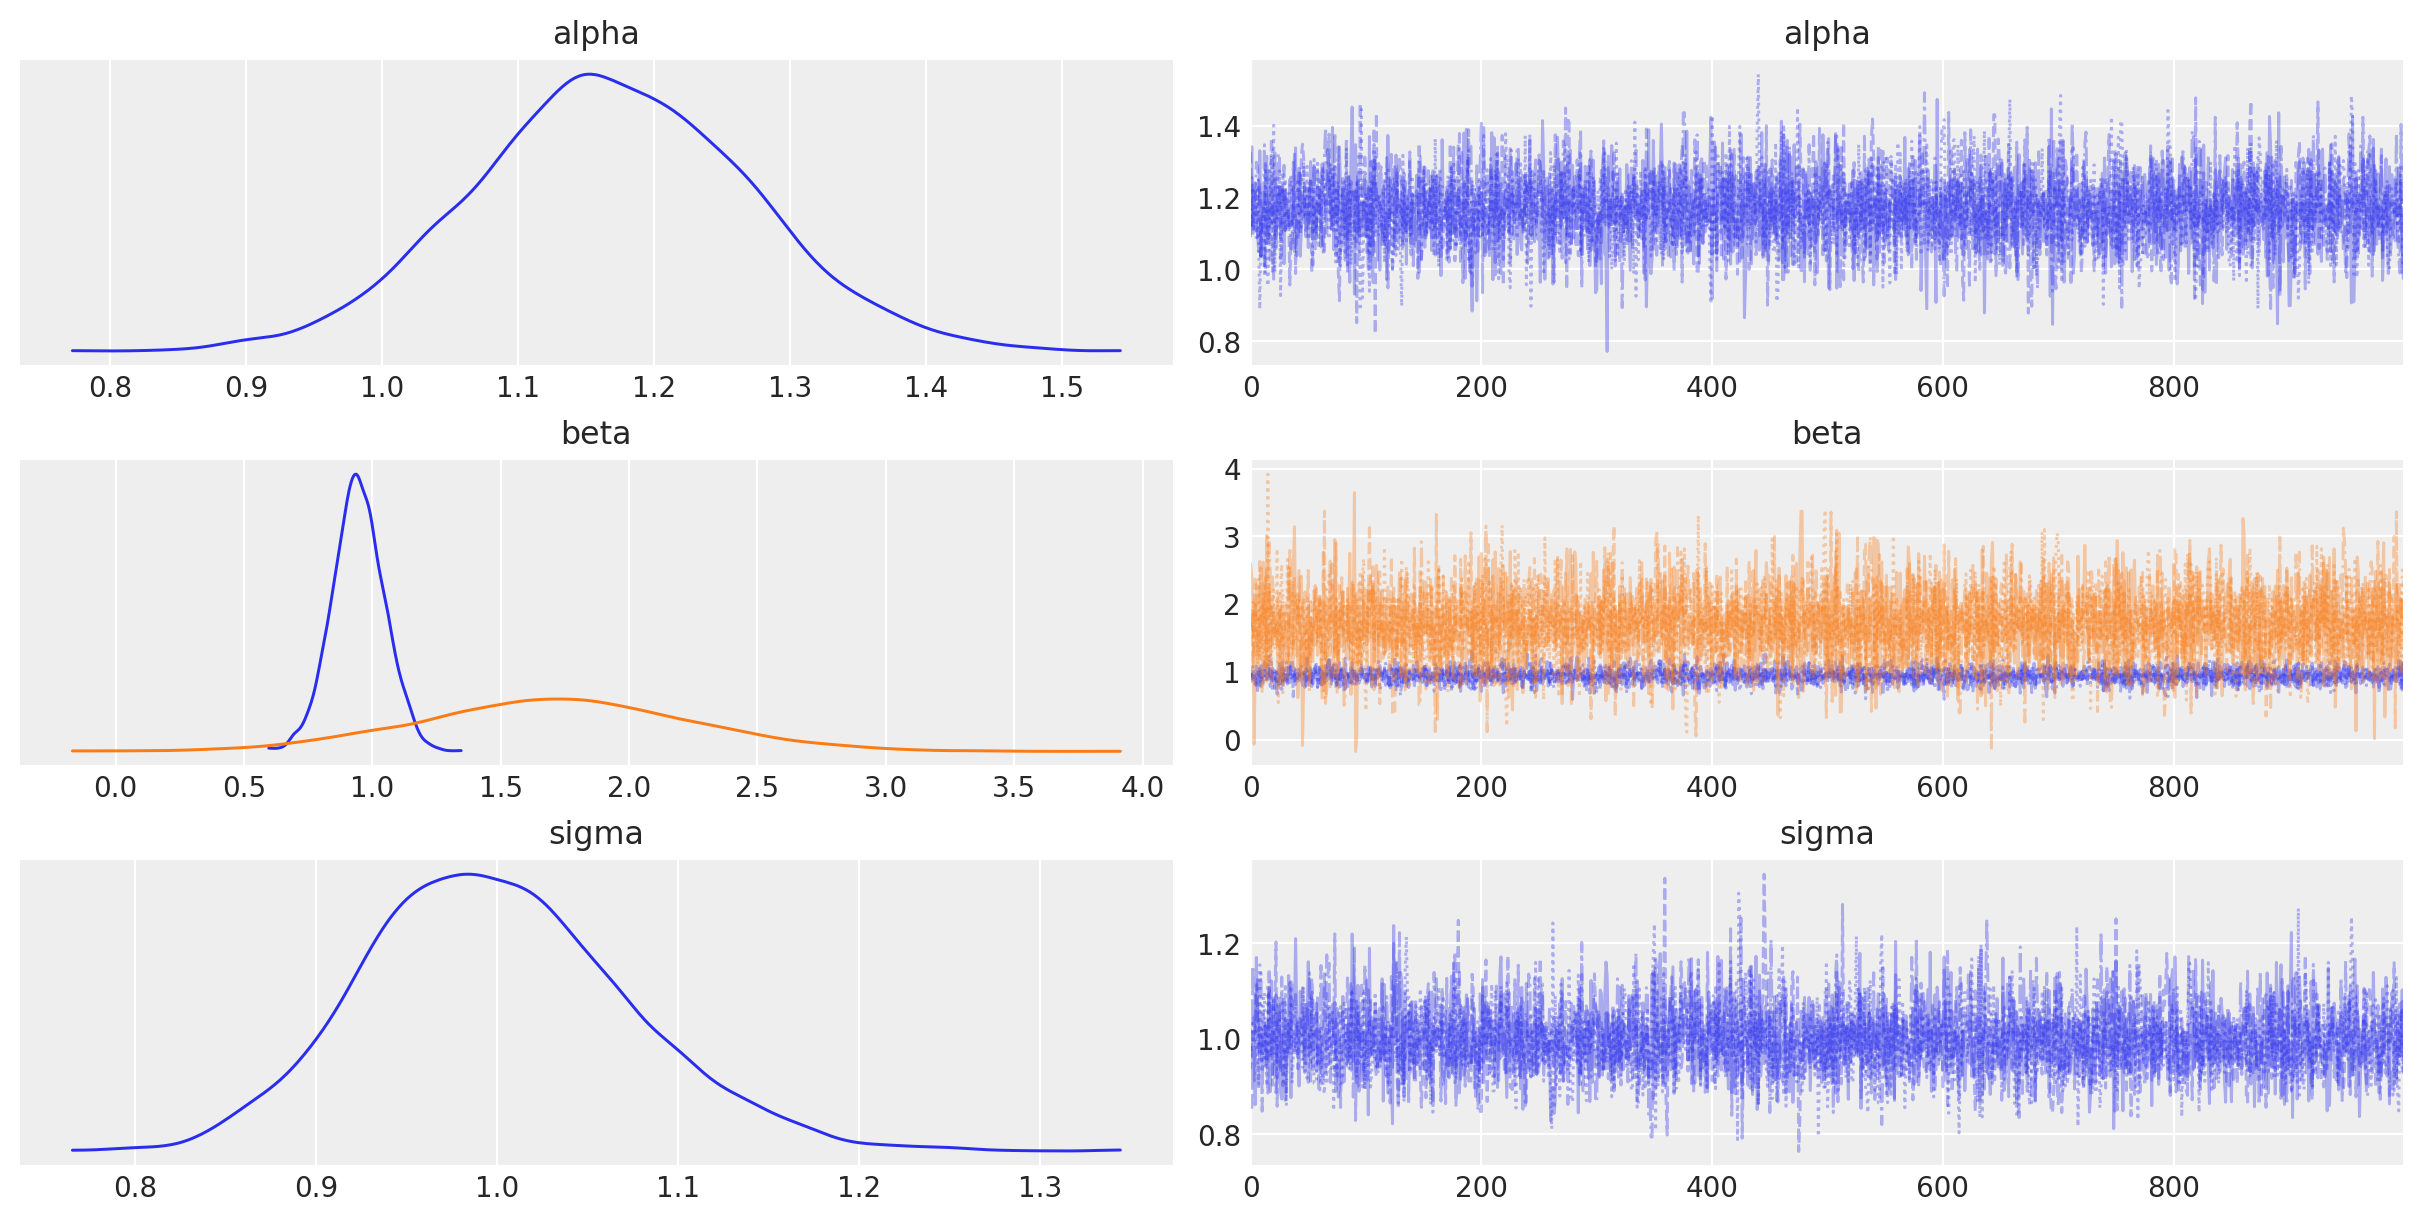

In [27]:
az.plot_trace(idata, combined=True)


In [28]:
az.summary(idata, round_to=2)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.17,0.10,0.98,1.37,0.00,0.00,6282.03,3132.14,1.0
beta[0],0.95,0.10,0.76,1.15,0.00,0.00,5991.64,3489.09,1.0
beta[1],1.71,0.53,0.69,2.68,0.01,0.01,6112.74,3153.76,1.0
sigma,1.00,0.07,0.87,1.14,0.00,0.00,4740.36,3407.45,1.0
